# Data Visualization Using `plotnine` and the grammar of graphics



## Cars Data

The Palmer Penguins dataset had a variety of column types with which to explore some nice visualizations. The `mtcars` dataset is another popular dataset for doing some simple data work, but does not contain the same types of variables.

Run the following code to load the `mtcars` dataset and explore the observations and variables contained within. To learn more about this dataset check out [this site](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/mtcars.html)

In [1]:
import statsmodels.api as sm
import pandas as pd

mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data
df = pd.DataFrame(mtcars)

In [2]:
df.dtypes


mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [3]:
df.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


The statement "the `mtcars` dataset does not contain the same types of variables as the penguins dataset" is a little true and a little false. There are no variables that contain text values, BUT there are variables that it makes sense to consider categorical variables. In most situations, it makes sense to treat the values of categorical variables as text values instead of numeric values.

Some of these variables, like the `cyl` variable, have numeric values that actually make sense as numbers (i.e. the number of cylinders in the engine). However, it doesn't make the most sense to "do math" with this type of variable (e.g. take averages and such) because there are so few different value this can take on AND they're an explicit choice made by the car manufacturer. So, it makes more sense to treat the `cyl` variable as a categorical variable despite it having numeric values.

You will need to keep these kinds of nuances about data in mind as you work with an increasing variety and richness of data, and do more complex things with them

Use the `astype()` method to convert the categorical variables of the `mtcars` (df) dataset to have text values in the code chunk below. We've done one for you!

In [4]:
df["am"] = df["am"].astype(str)
df["vs"] = df["vs"].astype(str)

df["cyl"] = df["cyl"].astype(str)
df["gear"] = df["gear"].astype(str)
df["carb"] = df["carb"].astype(str)

# mpg, disp, hp, drat, wt, and qsec are real measurements -- keep them numeric
df.dtypes


mpg     float64
cyl      object
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs       object
am       object
gear     object
carb     object
dtype: object

If you print out your new dataset, is it clear that the variables have been converted to text values? If so, how can you tell?

Let's see how `plotnine` treats these variables.


1\. Create side-by-side boxplots of the `mpg` variable by the different values of the `am` variable.

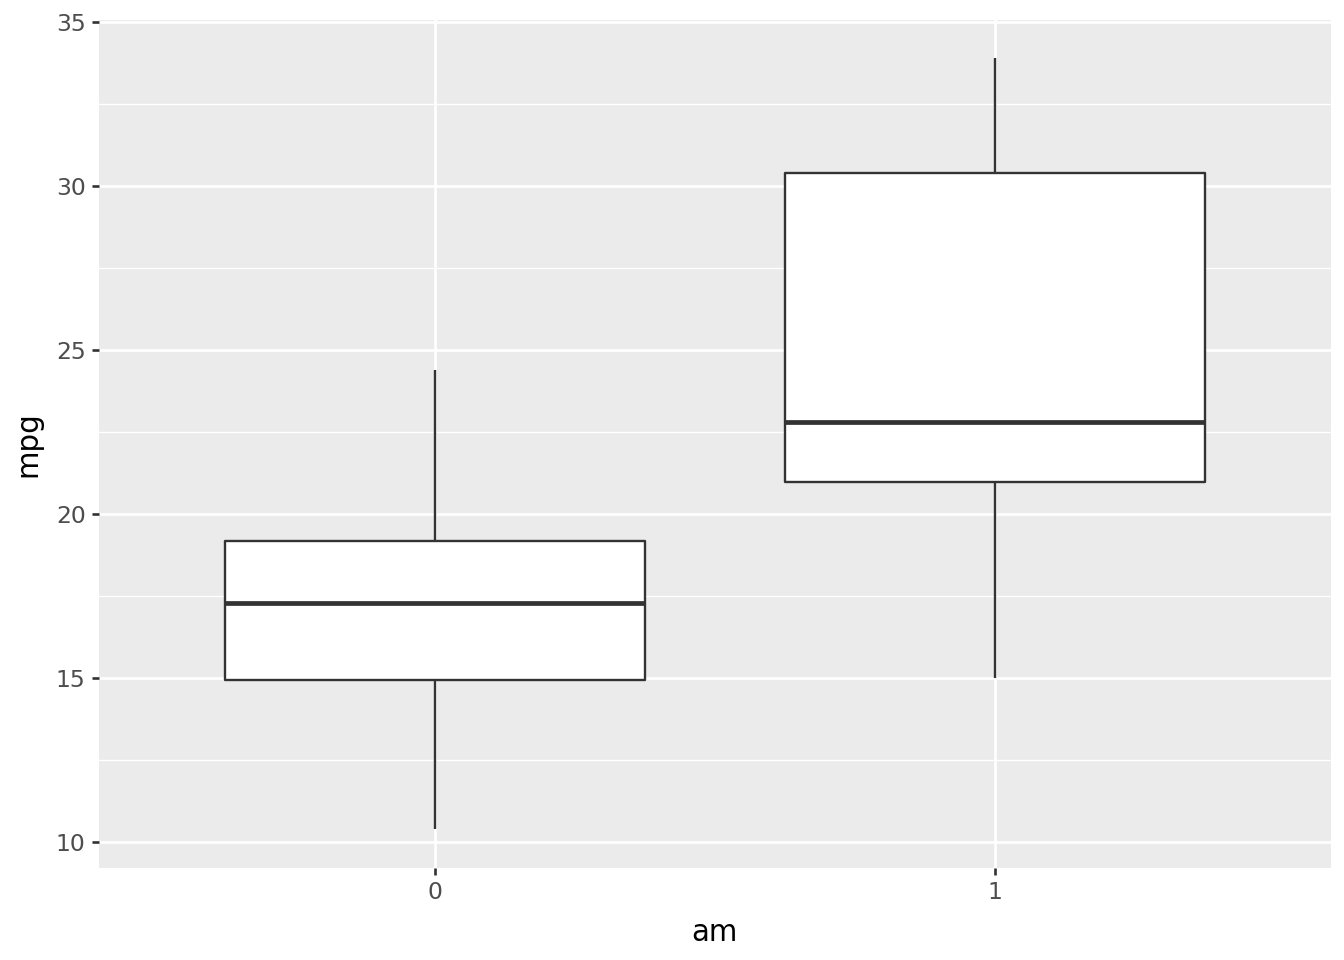

In [5]:
# Enter your code here
from plotnine import *                    # every plotting function in plotnine: ggplot, aes, geom_*, ...

(ggplot(df, aes(x = "am", y = "mpg")) + geom_boxplot())

2\. What happens if you convert the `am` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

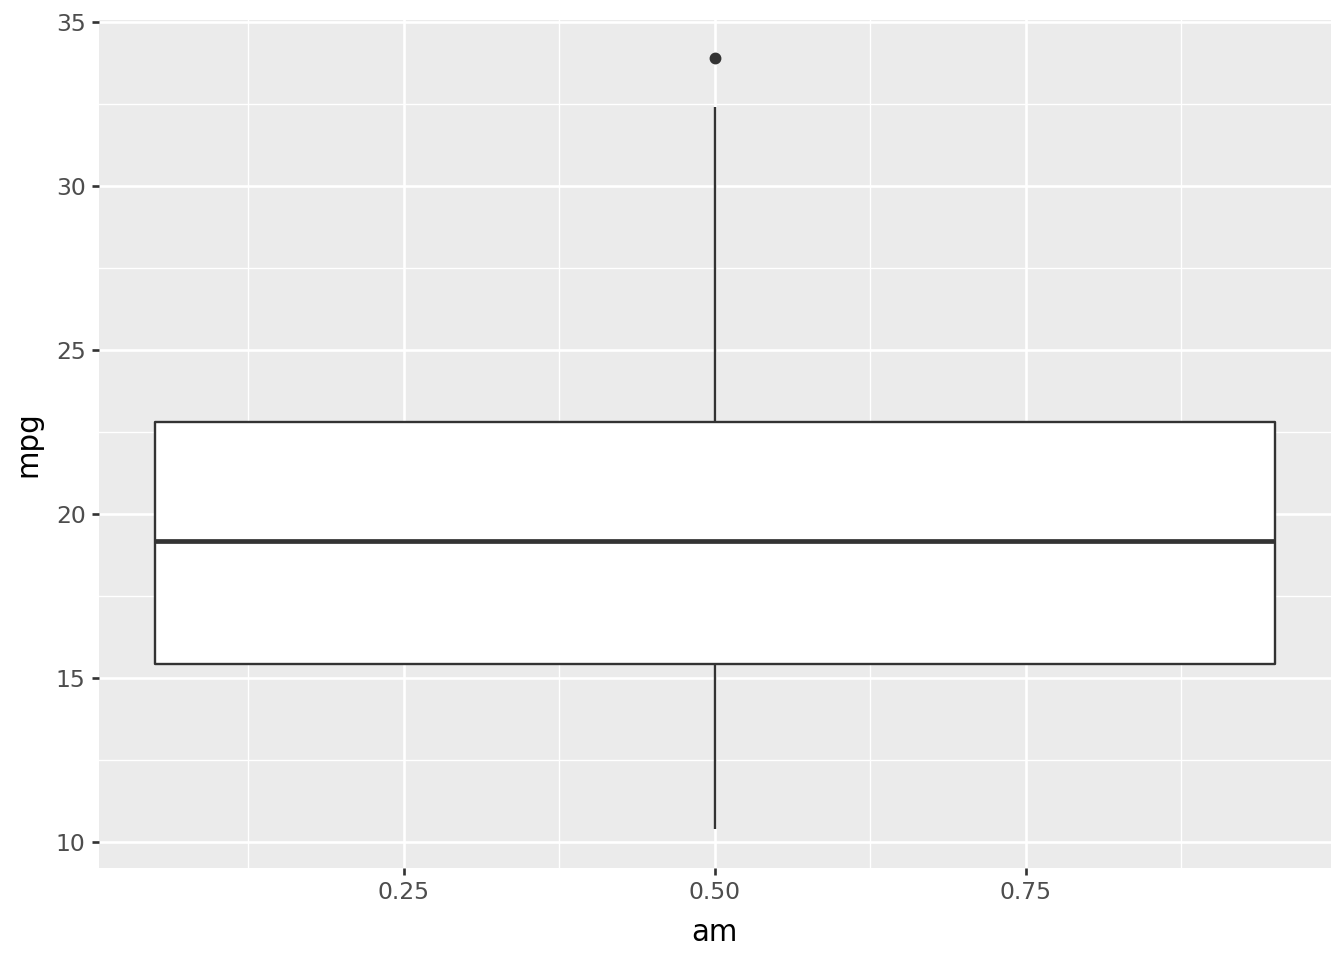

In [6]:
# Enter your code here
df_float = df.copy()
df_float["am"] = df_float["am"].astype(float)

(ggplot(df_float, aes(x = "am", y = "mpg")) + geom_boxplot())


3\. Create overlaid histograms of the `hp` variable for the different values of the `cyl` variable.

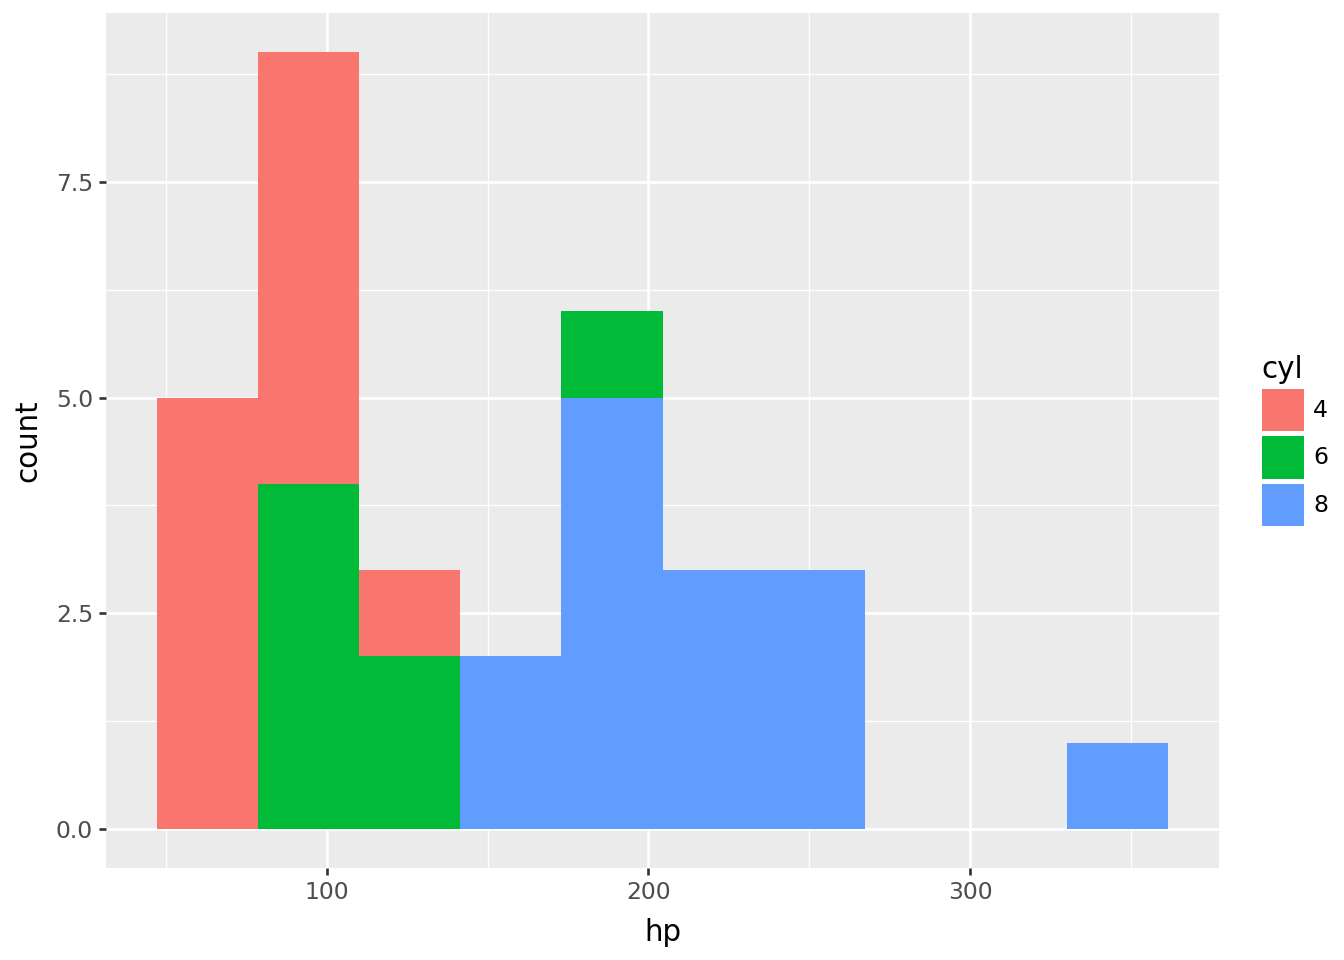

In [7]:
# Enter your code here
(ggplot(df, aes(x = "hp", fill = "cyl")) + geom_histogram(bins=10))


4\. What happens if you convert the `cyl` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

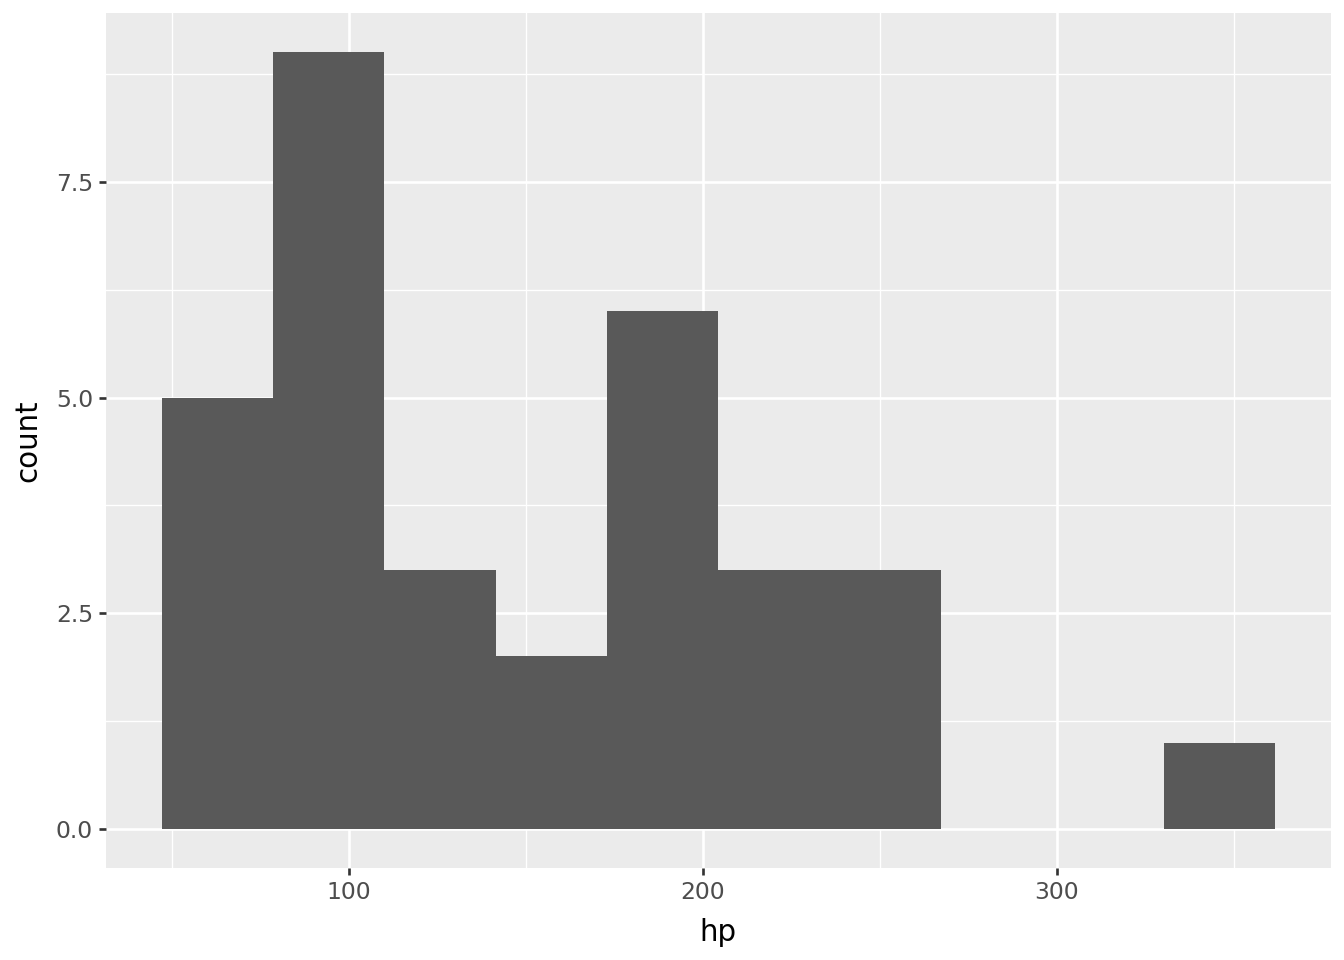

In [8]:
# Enter your code here
df_cyl_float = df.copy()
df_cyl_float["cyl"] = df_cyl_float["cyl"].astype(float)

(ggplot(df_cyl_float, aes(x = "hp", fill = "cyl")) + geom_histogram(bins = 10))


5\. Choose a new `geometry` from the [data-to-viz website](https://www.data-to-viz.com/) or look in the [`plotnine` graph gallery](https://python-graph-gallery.com/plotnine/) for a graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

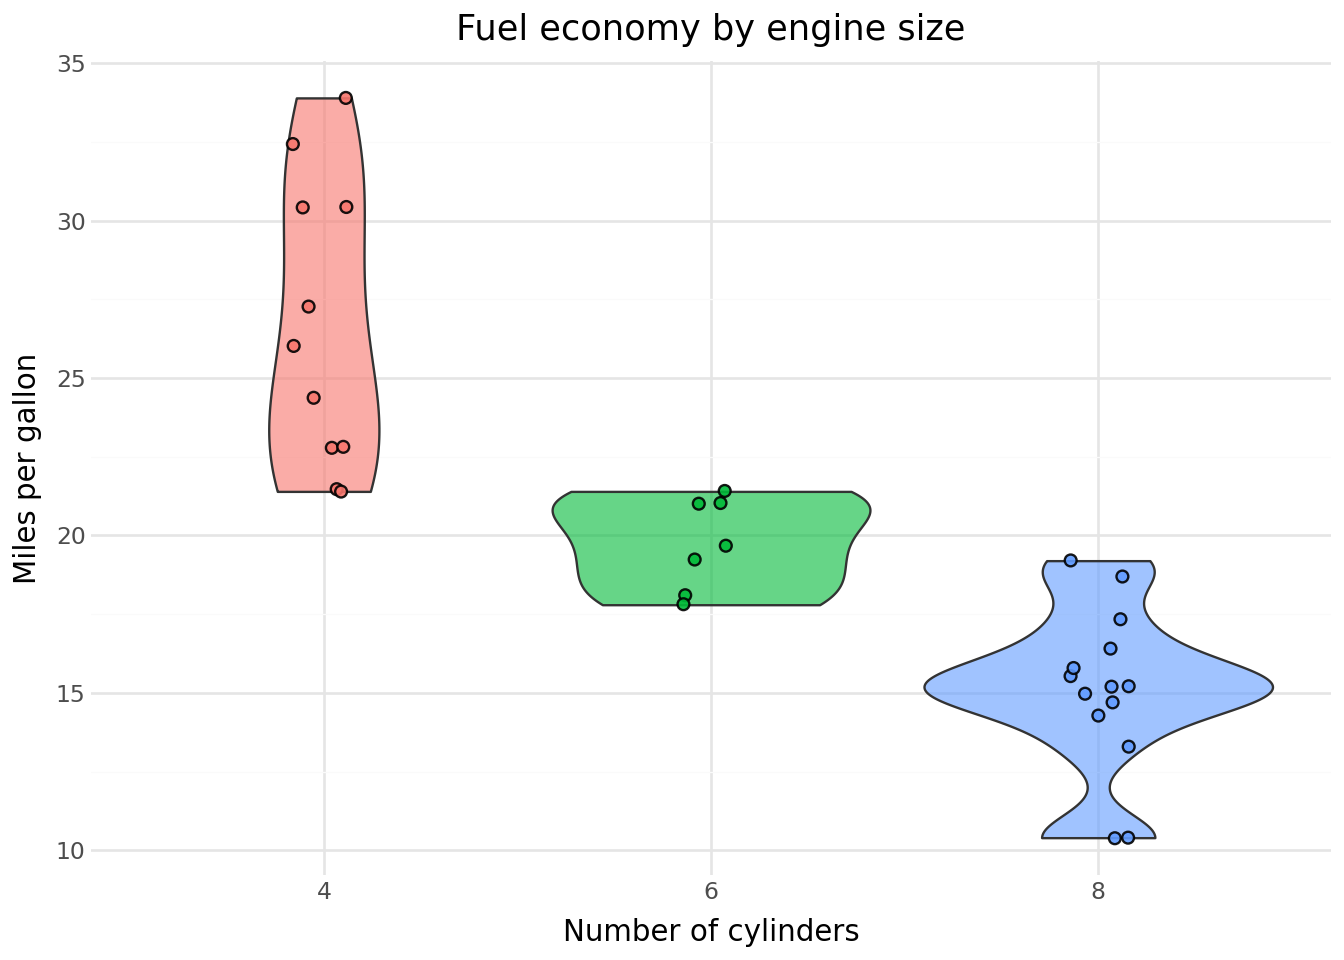

In [9]:
# Enter your code here
# Violin plot (from data-to-viz, "one numeric + one categorical" family)
# with the raw observations jittered on top.

(ggplot(df, aes(x = "cyl", y = "mpg", fill = "cyl"))
   + geom_violin(alpha = 0.6, show_legend = False)
   + geom_jitter(width = 0.08, size = 2, alpha = 0.9, show_legend = False)
   + labs(title = "Fuel economy by engine size",
          x = "Number of cylinders",
          y = "Miles per gallon")
   + theme_minimal())


6\. Repeat the previous part for another graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

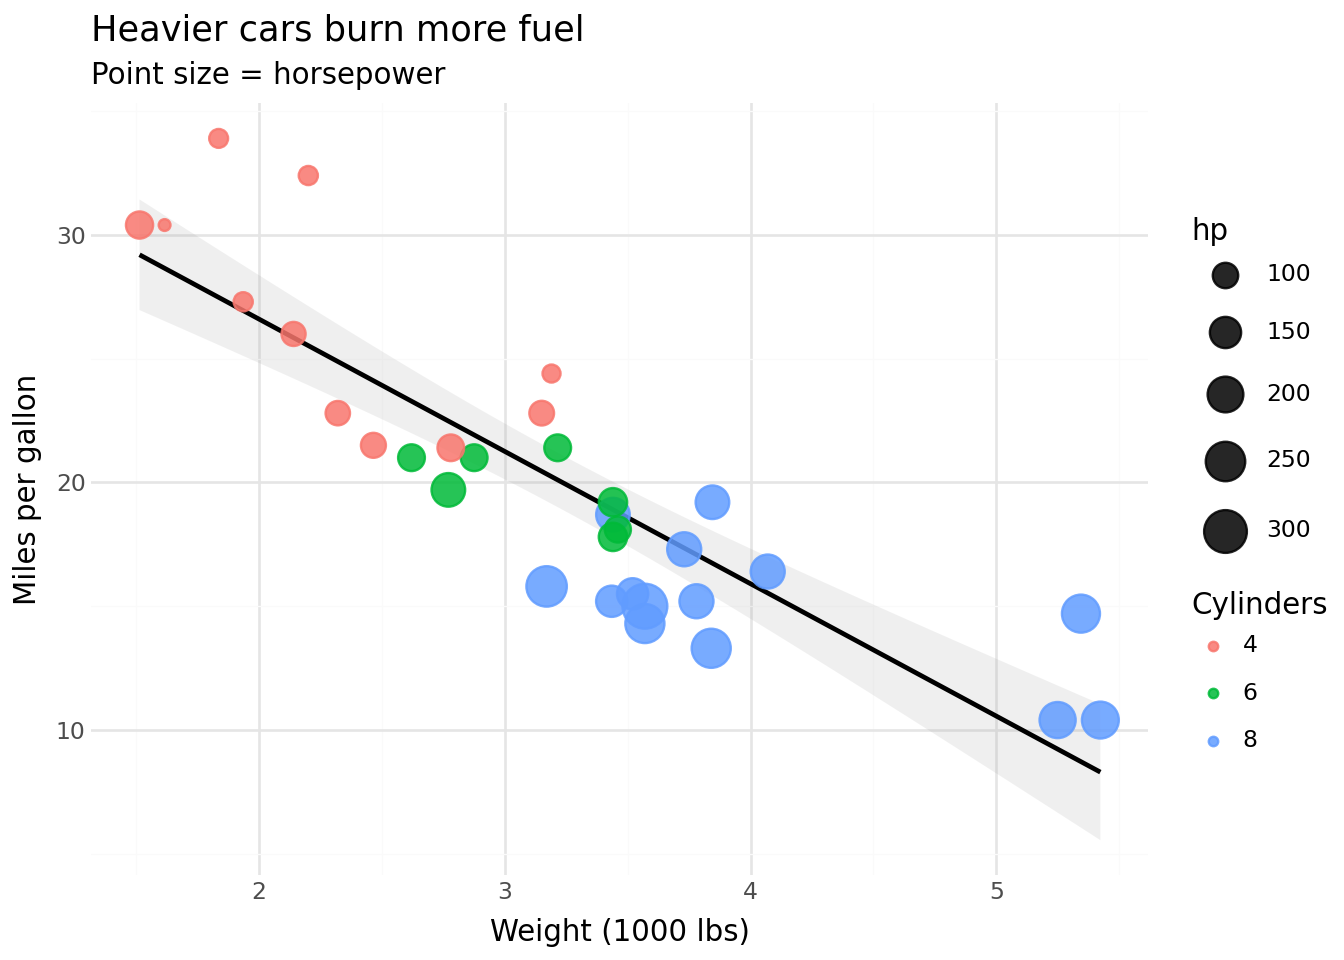

In [10]:
# Enter your code here


(ggplot(df, aes(x = "wt", y = "mpg"))
   + geom_smooth(method = "lm", color = "black", alpha = 0.15)
   + geom_point(aes(color = "cyl", size = "hp"), alpha = 0.85)
   + scale_size_continuous(range = (2, 9))
   + labs(title = "Heavier cars burn more fuel",
          subtitle = "Point size = horsepower",
          x = "Weight (1000 lbs)",
          y = "Miles per gallon",
          color = "Cylinders",
          size = "hp")
   + theme_minimal())


## FEV Data

(You saw this data set in [GSB 518](https://kevin-davisross.quarto.pub/gsb518-notes/hw-09.html#problem-3).) Do non-smokers have better lungs than smokers? One measure of lung function is forced expiratory volume (FEV), the amount of air (in liters) an individual can exhale in the first second of forceful breath. Larger values of FEV are indicative of better functioning lungs. In a study, FEV was measured for a group of 654 subjects, along with whether they smoked and other variables like age (years). [Here is the data.](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv)

[This plot](https://drive.google.com/file/d/1dm7U1cpVpHrbNZrBymOdmtkhMX3U7BwU/view?usp=sharing) was made using `plotly`. Use AI to help reproduce it using `plotnine`. Think in terms of the grammar of graphics and the design of the plot and write prompts like "The x-axis is mapped to Age". It might help to [try the two practice activities in Section 3.6.3 first](https://ds-ml-with-python.github.io/Course-Textbook/02-plotnine.html#try-it-out). (Hint: this is really 3 separate plots. Consider using the `patchworklib` package, which you need to install in Colab space first.)


In [11]:
# Enter your code here
import pandas as pd
from plotnine import *

url = "https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv"
fev = pd.read_csv(url)

# The file stores age in MONTHS -- the plot wants years.
fev["Age"] = fev["Age (months)"] / 12

fev.head()



,ID,Smoking status,FEV,Height,Age (months),Age
0,201,non-smoker,2.884,69.0,132,11.000000
1,202,non-smoker,2.328,64.0,120,10.000000
2,301,non-smoker,1.708,57.0,108,9.000000
3,341,non-smoker,3.381,63.0,172,14.333333
4,351,non-smoker,2.170,58.0,130,10.833333


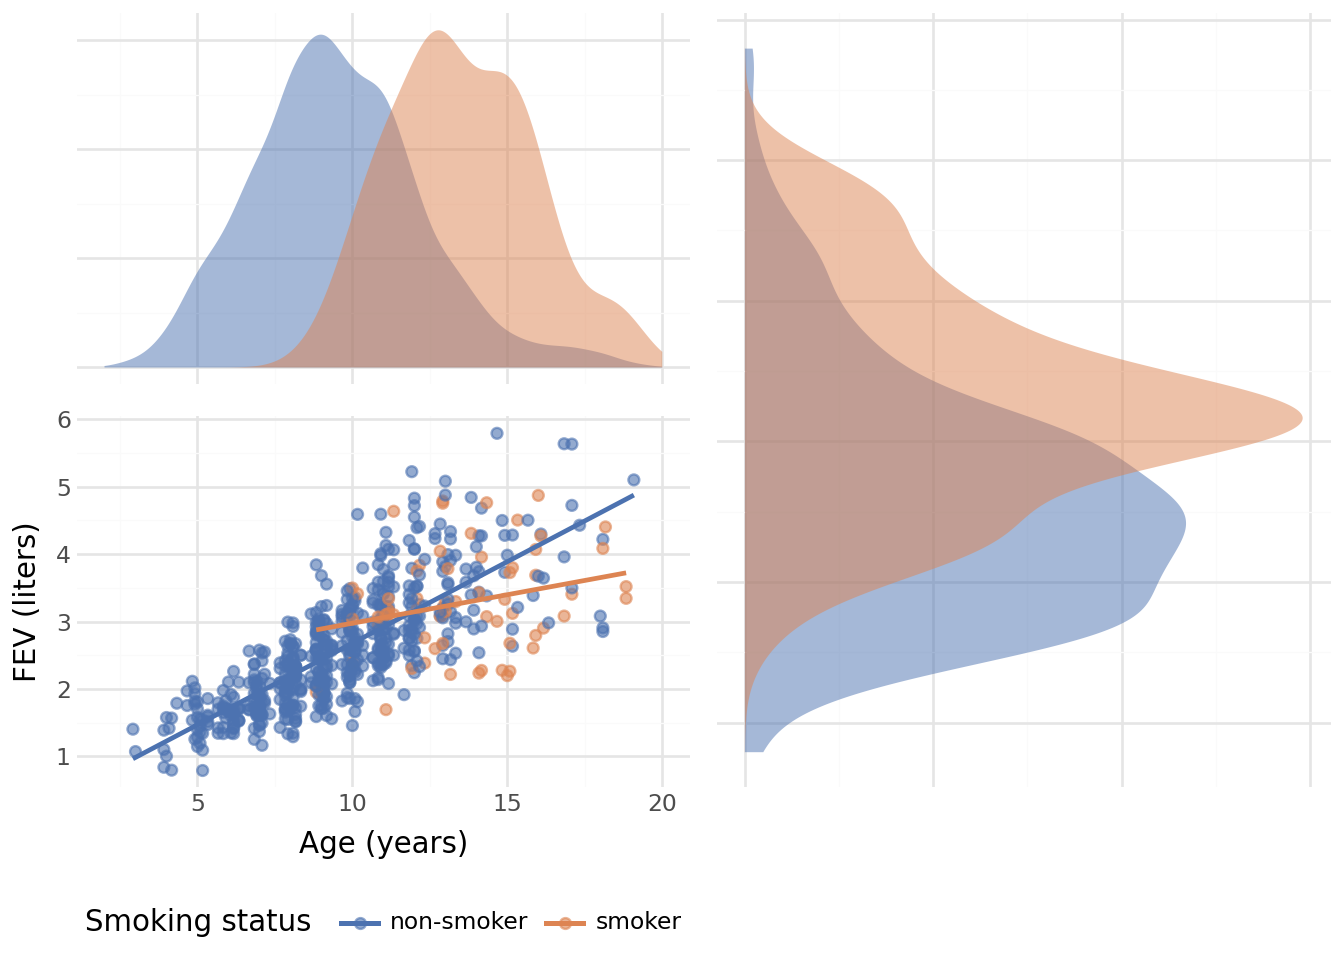

In [12]:
# The grammar of this figure, stated one mapping at a time:
#   main panel : x -> Age, y -> FEV, color -> Smoking status,
#                geom_point for the 654 subjects + geom_smooth for the trend
#   top panel  : the marginal distribution of Age,  split by Smoking status
#   right panel: the marginal distribution of FEV,  split by Smoking status
# plotnine >= 0.14 composes plots with "/" (stack) and "|" (side by side),
# so patchworklib is not needed.

pal = ["#4C72B0", "#DD8452"]   # non-smoker, smoker

# strip the axes off the marginal panels so they read as context, not data
blank = theme(legend_position = "none",
              axis_title = element_blank(),
              axis_text = element_blank(),
              axis_ticks = element_blank())

top = (ggplot(fev, aes(x = "Age", fill = "Smoking status"))
         + geom_density(alpha = 0.5, color = "none")
         + scale_fill_manual(values = pal)
         + scale_x_continuous(limits = (2, 20))
         + theme_minimal() + blank)

main = (ggplot(fev, aes(x = "Age", y = "FEV", color = "Smoking status"))
          + geom_point(alpha = 0.6, size = 1.8)
          + geom_smooth(method = "lm", se = False)
          + scale_color_manual(values = pal)
          + scale_x_continuous(limits = (2, 20))
          + labs(x = "Age (years)", y = "FEV (liters)")
          + theme_minimal()
          + theme(legend_position = "bottom"))

right = (ggplot(fev, aes(x = "FEV", fill = "Smoking status"))
           + geom_density(alpha = 0.5, color = "none")
           + scale_fill_manual(values = pal)
           + coord_flip()
           + theme_minimal() + blank)

(top / main) | right



## Olympic Men's Gymnastics Data

[This file](https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv) contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

1\. Your goal will be to create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. But first...


This data is in "wide format" in that the scores are spread over six columns.

| Floor score | Pommel score | Rings score | Vault score | Pbar score | Hbar score |
|------------:|-------------:|------------:|------------:|-----------:|-----------:|
|        15.0 |         14.5 |        15.2 |        16.1 |       14.6 |       15.0 |


In order to produce some plots (and work with the grammar of graphics more fully), you might need to reformat the data so that it is "long format" with one column for score and a new column for "event".

| Event  | Score |
|--------|------:|
| Floor  |  15.0 |
| Pommel |  14.5 |
| Rings  |  15.2 |
| Vault  |  16.1 |
| Pbar   |  14.6 |
| Hbar   |  15.0 |

Create a new data frame with the scores in long format, with columns labeled "Event" and "Score". There are a few ways to do this, so see what you can find!


In [13]:
# YOUR CODE HERE
import pandas as pd

url = "https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv"
gym = pd.read_csv(url)
gym.head()



,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012


In [14]:
events = ["Floor Exercise", "Pommelled Horse", "Rings",
          "Horse Vault", "Parallel Bars", "Horizontal Bar"]


id_cols = [c for c in gym.columns if c not in events]

gym_long = gym.melt(id_vars    = id_cols,
                    value_vars = events,
                    var_name   = "Event",
                    value_name = "Score")

gym_long = gym_long.dropna(subset = ["Score"])


short = {"Floor Exercise": "Floor", "Pommelled Horse": "Pommel",
         "Rings": "Rings", "Horse Vault": "Vault",
         "Parallel Bars": "Pbar", "Horizontal Bar": "Hbar"}
gym_long["Event"] = pd.Categorical(gym_long["Event"].map(short),
                                   categories = list(short.values()),
                                   ordered = True)

print(gym.shape, "->", gym_long.shape)
gym_long[["Gymnast", "Year", "Round", "Event", "Score"]].head(12)



(351, 12) -> (1937, 8)


,Gymnast,Year,Round,Event,Score
0,Danell Leyva,2012,Qualification,Floor,15.100
1,David Belyavsky,2012,Qualification,Floor,15.100
2,Fabian HambÃ¼chen,2012,Qualification,Floor,15.133
3,John Orozco,2012,Qualification,Floor,15.166
4,Kristian Thomas,2012,Qualification,Floor,15.366
5,Mykola Kuksenkov,2012,Qualification,Floor,14.533
6,Marcel Nguyen,2012,Qualification,Floor,15.433
7,Emin Garibov,2012,Qualification,Floor,14.533
8,Kohei Uchimura,2012,Qualification,Floor,15.766
9,Daniel Purvis,2012,Qualification,Floor,15.200


2\. Now create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. Be creative! Share your graph with a classmate and discuss why you designed it the way you did.

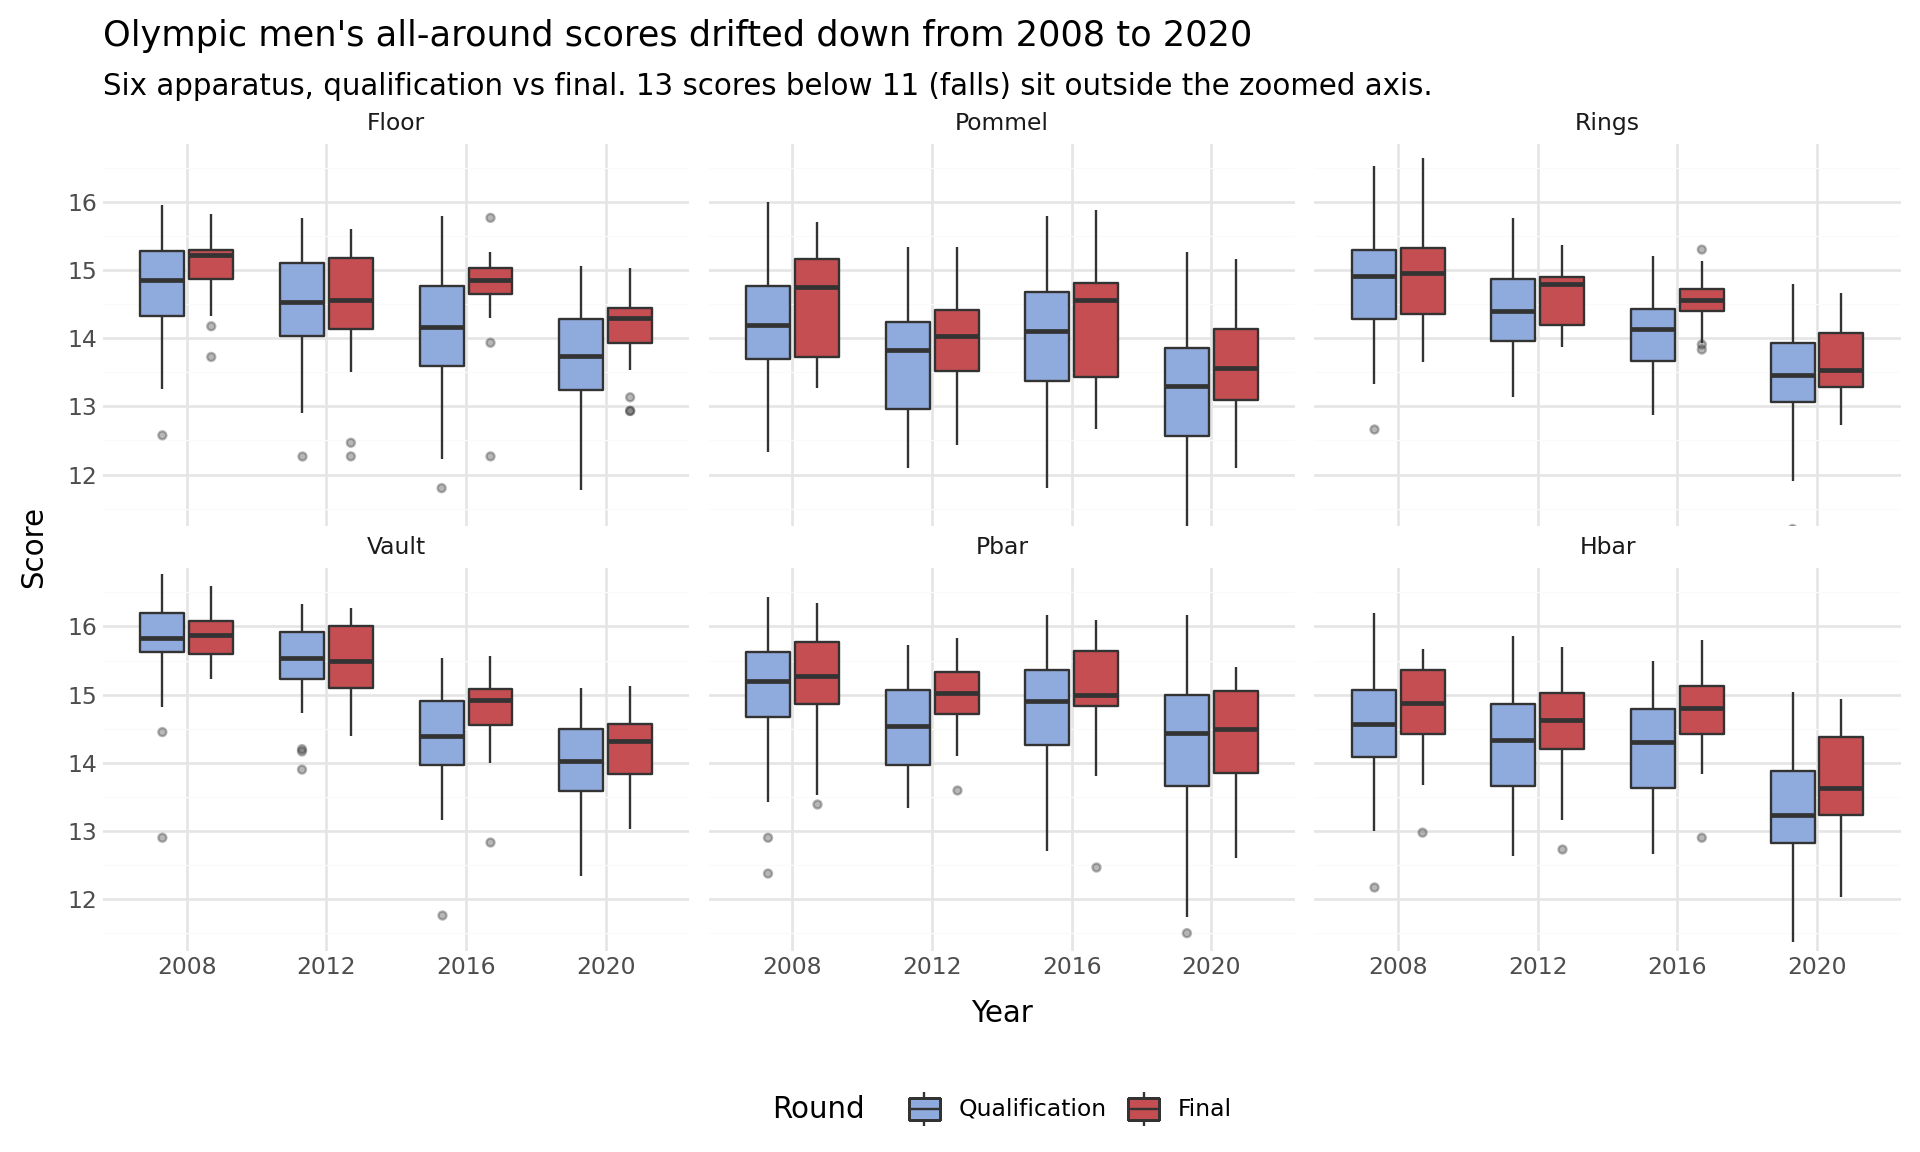

In [15]:
# YOUR CODE HERE
from plotnine import *


gym_long["Round"] = pd.Categorical(gym_long["Round"],
                                   categories = ["Qualification", "Final"],
                                   ordered = True)


gym_long["Year"] = gym_long["Year"].astype(str)

(ggplot(gym_long, aes(x = "Year", y = "Score", fill = "Round"))
   + geom_boxplot(outlier_alpha = 0.35, outlier_size = 1.2, width = 0.7)
   + facet_wrap("Event", nrow = 2)
   + coord_cartesian(ylim = (11.5, 16.6))
   + scale_fill_manual(values = ["#8FAADC", "#C44E52"])
   + labs(title = "Olympic men's all-around scores drifted down from 2008 to 2020",
          subtitle = "Six apparatus, qualification vs final. 13 scores below 11 (falls) sit outside the zoomed axis.",
          x = None, y = "Score", fill = "Round")
   + theme_minimal()
   + theme(legend_position = "bottom", figure_size = (10, 6)))

